In [1]:
import mysql.connector

# Connect to MySQL
connection = mysql.connector.connect(
    host="localhost",      # or your server IP, e.g., "127.0.0.1"
    user="root",           # your MySQL username
    password="root",  # your MySQL password
    database="demo"   # optional: specify a database
)

# Check connection
if connection.is_connected():
    print("✅ Successfully connected to MySQL!")

# Create a cursor object to run queries
cursor = connection.cursor()

# Example query
cursor.execute("SHOW DATABASES")

print("📂 Databases in MySQL:")
for db in cursor:
    print(db)

# Close the connection
cursor.close()
connection.close()


✅ Successfully connected to MySQL!
📂 Databases in MySQL:
('branch',)
('demo',)
('information_schema',)
('mysql',)
('performance_schema',)
('school',)
('sys',)


In [2]:
import mysql.connector

# Connect to MySQL server (without database first)
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root"
)

if connection.is_connected():
    print("✅ Connected to MySQL Server")

cursor = connection.cursor()

# 1. Create database
cursor.execute("CREATE DATABASE IF NOT EXISTS school")
print("✅ Database 'school' created!")

# 2. Switch to 'school' database
cursor.execute("USE school")

# 3. Create students table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS students (
        id INT AUTO_INCREMENT PRIMARY KEY,
        name VARCHAR(50),
        age INT,
        grade VARCHAR(10)
    )
""")
print("✅ Table 'students' created!")

# 4. Insert data
sql = "INSERT INTO students (name, age, grade) VALUES (%s, %s, %s)"
values = [
    ("Amit", 14, "8th"),
    ("Priya", 15, "9th"),
    ("Rohan", 13, "7th")
]
cursor.executemany(sql, values)
connection.commit()
print("✅ Data inserted successfully!")

# 5. Fetch and display data
cursor.execute("SELECT * FROM students")
rows = cursor.fetchall()

print("\n📋 Students Table Data:")
for row in rows:
    print(row)

# 6. Close
cursor.close()
connection.close()


✅ Connected to MySQL Server


✅ Database 'school' created!
✅ Table 'students' created!
✅ Data inserted successfully!

📋 Students Table Data:
(1, 'Amit', 14, '8th')
(2, 'Priya', 15, '9th')
(3, 'Rohan', 13, '7th')
(4, 'Amit', 14, '8th')
(5, 'Priya', 15, '9th')
(6, 'Rohan', 13, '7th')
(7, 'Amit', 14, '8th')
(8, 'Priya', 15, '9th')
(9, 'Rohan', 13, '7th')


In [3]:
import mysql.connector
import pandas as pd

# Connect to MySQL
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="demo"
)

# Query data
df = pd.read_sql("SELECT * FROM students", connection)
print(df.head(150))


     Student_ID   Student_Name  Student_Rollno Student_Branch  Student_Mark
0             1     Amit Kumar            1171            CSE            86
1             2    Priya Singh            1172             IT            92
2             3    Rahul Verma            1173            ECE            78
3             4    Sneha Gupta            1174             ME            88
4             5  Ananya Sharma            1175            CSE            95
..          ...            ...             ...            ...           ...
145         146    Sweta Kohli            1316            CSE            93
146         147  Arvind Kapoor            1317             IT            82
147         148    Riya Tandon            1318            ECE            87
148         149  Ajay Kulkarni            1319             ME            88
149         150   Poonam Arora            1320             CE            90

[150 rows x 5 columns]


C:\Users\anany\AppData\Local\Temp\ipykernel_44520\3666122461.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM students", connection)


In [5]:
# Show first 5 rows
print(df.head())

   Student_ID   Student_Name  Student_Rollno Student_Branch  Student_Mark
0           1     Amit Kumar            1171            CSE            86
1           2    Priya Singh            1172             IT            92
2           3    Rahul Verma            1173            ECE            78
3           4    Sneha Gupta            1174             ME            88
4           5  Ananya Sharma            1175            CSE            95


In [6]:
# Show last 5 rows
df.tail()

,Student_ID,Student_Name,Student_Rollno,Student_Branch,Student_Mark
145,146,Sweta Kohli,1316,CSE,93
146,147,Arvind Kapoor,1317,IT,82
147,148,Riya Tandon,1318,ECE,87
148,149,Ajay Kulkarni,1319,ME,88
149,150,Poonam Arora,1320,CE,90


In [7]:
# Shape of dataset (rows, columns)
df.shape

(150, 5)

In [8]:
# Column names
df.columns

Index(['Student_ID', 'Student_Name', 'Student_Rollno', 'Student_Branch',
       'Student_Mark'],
      dtype='object')

In [9]:
# Data types of each column
df.dtypes

Student_ID         int64
Student_Name      object
Student_Rollno     int64
Student_Branch    object
Student_Mark       int64
dtype: object

In [10]:
# Summary of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      150 non-null    int64 
 1   Student_Name    150 non-null    object
 2   Student_Rollno  150 non-null    int64 
 3   Student_Branch  150 non-null    object
 4   Student_Mark    150 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 6.0+ KB


In [11]:
# Statistics (only for numeric columns)
df.describe()

,Student_ID,Student_Rollno,Student_Mark
count,150.000000,150.000000,150.000000
mean,75.500000,1245.500000,85.553333
std,43.445368,43.445368,5.676440
min,1.000000,1171.000000,72.000000
25%,38.250000,1208.250000,82.000000
50%,75.500000,1245.500000,86.000000
75%,112.750000,1282.750000,90.000000
max,150.000000,1320.000000,96.000000


In [12]:
# Count missing values per column
df.isnull().sum()

Student_ID        0
Student_Name      0
Student_Rollno    0
Student_Branch    0
Student_Mark      0
dtype: int64

In [13]:
# Check if any missing values exist
df.isnull().any()

Student_ID        False
Student_Name      False
Student_Rollno    False
Student_Branch    False
Student_Mark      False
dtype: bool

In [14]:
# Check duplicat
df.duplicated().sum()

np.int64(0)

In [15]:
# Unique values in Branch
df['Student_Branch'].unique()

array(['CSE', 'IT', 'ECE', 'ME', 'CE', 'EEE'], dtype=object)

In [16]:
# Count of students per branch
df['Student_Branch'].value_counts()

Student_Branch
CSE    32
IT     26
ECE    26
ME     26
CE     20
EEE    20
Name: count, dtype: int64

In [17]:
# Top 5 students by marks
df.sort_values(by="Student_Mark", ascending=False).head()

,Student_ID,Student_Name,Student_Rollno,Student_Branch,Student_Mark
19,20,Arjun Mishra,1190,CSE,96
4,5,Ananya Sharma,1175,CSE,95
57,58,Aishwarya Rao,1228,IT,95
73,74,Isha Saxena,1244,ME,95
92,93,Harshal Patil,1263,IT,94


In [24]:
# Students with marks less than 40
df[df['Student_Mark'] < 75]

,Student_ID,Student_Name,Student_Rollno,Student_Branch,Student_Mark
6,7,Simran Yadav,1177,EEE,73
20,21,Amit Sharma,1191,EEE,72
33,34,Sneha Singh,1204,EEE,74
45,46,Ravi Sharma,1216,EEE,73
88,89,Ramesh Agarwal,1259,ME,74


In [25]:
# Select specific columns
df[['Student_Name', 'Student_Mark']].head()

,Student_Name,Student_Mark
0,Amit Kumar,86
1,Priya Singh,92
2,Rahul Verma,78
3,Sneha Gupta,88
4,Ananya Sharma,95


In [26]:
# Select a single student by ID
df[df['Student_ID'] == 101]

,Student_ID,Student_Name,Student_Rollno,Student_Branch,Student_Mark
100,101,Arjun Nair,1271,CSE,87


In [28]:
# Average marks
df['Student_Mark'].mean()

np.float64(85.55333333333333)

In [29]:
# Max & Min marks
df['Student_Mark'].max(), df['Student_Mark'].min()


(np.int64(96), np.int64(72))

In [30]:
# Average marks per branch
df.groupby('Student_Branch')['Student_Mark'].mean()

Student_Branch
CE     86.600000
CSE    87.781250
ECE    84.000000
EEE    81.150000
IT     88.269231
ME     84.230769
Name: Student_Mark, dtype: float64

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

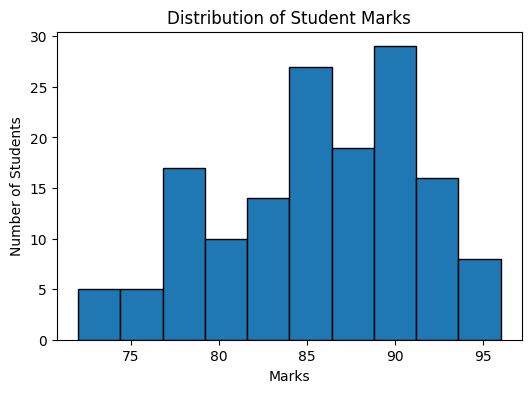

In [32]:
# 1. Histogram of marks
plt.figure(figsize=(6,4))
plt.hist(df['Student_Mark'], bins=10, edgecolor='black')
plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

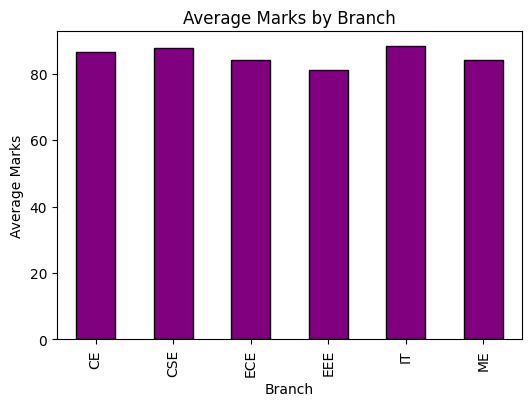

In [36]:
# 2. Average marks per branch (Bar Chart)
branch_avg = df.groupby("Student_Branch")['Student_Mark'].mean()
plt.figure(figsize=(6,4))
branch_avg.plot(kind='bar', color='purple', edgecolor='black')
plt.title("Average Marks by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Marks")
plt.show()

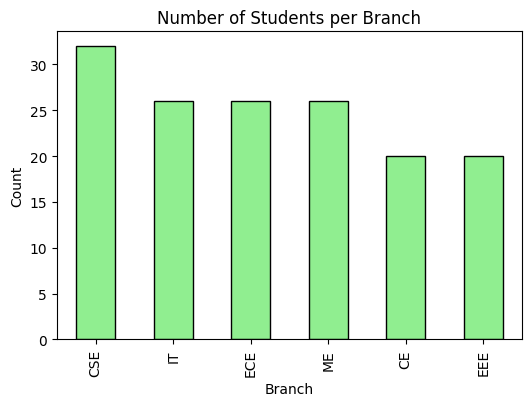

In [37]:
# 3. Count of students in each branch
branch_count = df['Student_Branch'].value_counts()
plt.figure(figsize=(6,4))
branch_count.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title("Number of Students per Branch")
plt.xlabel("Branch")
plt.ylabel("Count")
plt.show()

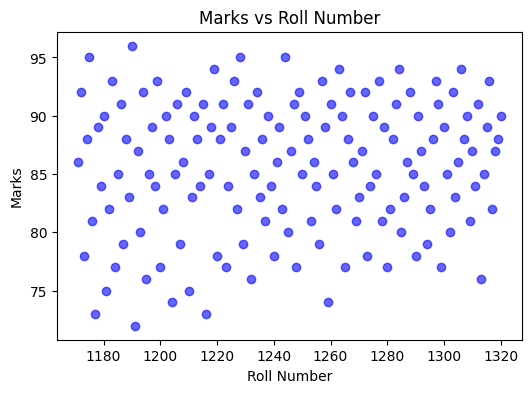

In [46]:
# 4. Scatter plot of Roll Number vs Marks
plt.figure(figsize=(6,4))
plt.scatter(df['Student_Rollno'], df['Student_Mark'], c='blue', alpha=0.6)
plt.title("Marks vs Roll Number")
plt.xlabel("Roll Number")
plt.ylabel("Marks")
plt.show()

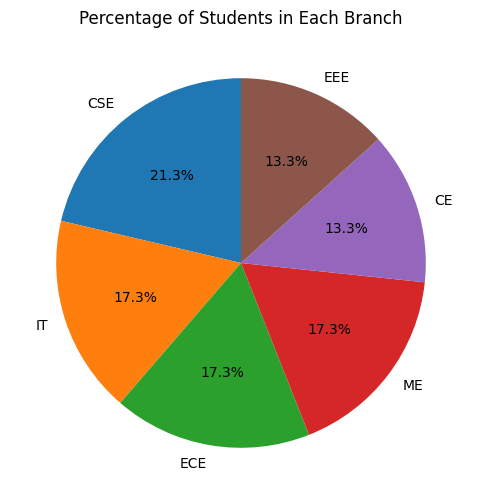

In [ ]:
# 5. Pie chart of students per branch
branch_count = df['Student_Branch'].value_counts()    # counts how many students are in each branch
plt.figure(figsize=(6,6))
plt.pie(branch_count, 
        labels=branch_count.index,       # labels = branch names
        autopct='%1.1f%%',               # show percentage with 1 decimal place(inside slices)
        startangle=90)                   # rotate chart so it starts from 12 o’clock

plt.title("Percentage of Students in Each Branch")
plt.show()

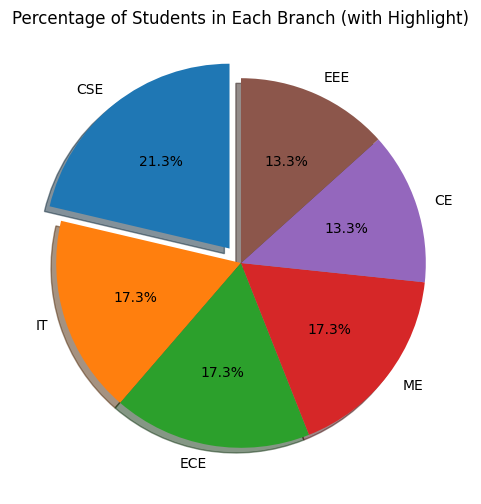

In [54]:
# Pie chart with explode effect
branch_count = df['Student_Branch'].value_counts()

plt.figure(figsize=(6,6))

# Create explode list (e.g., highlight the first branch)
explode = [0.1 if i == 0 else 0 for i in range(len(branch_count))]
# 0.1 → how far the slice pops out (10%)
# here, only the first branch (branch_count.index[0]) will pop out

plt.pie(
    branch_count,
    labels=branch_count.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,          #explode=explode → Moves slices outward. Example: [0.1, 0, 0, 0] → only the first slice pops out.
    shadow=True               # optional: adds shadow for 3D effect
)

plt.title("Percentage of Students in Each Branch (with Highlight)")
plt.show()


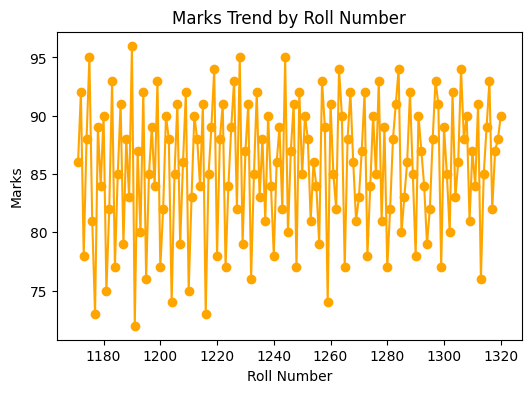

In [51]:
# 6. Line plot of roll number vs marks
plt.figure(figsize=(6,4))
plt.plot(df['Student_Rollno'], df['Student_Mark'], marker='o', linestyle='-', color='orange')
               # draw a small circle at each data point (marker=o)
               # connect points with a straight line (linestyle= '-' )


plt.title("Marks Trend by Roll Number")
plt.xlabel("Roll Number")
plt.ylabel("Marks")
plt.show()

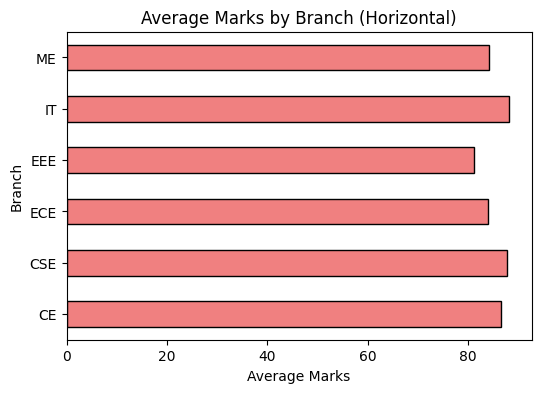

In [50]:
# 7. Horizontal bar chart of average marks by branch
plt.figure(figsize=(6,4))
branch_avg = df.groupby("Student_Branch")['Student_Mark'].mean()
              # Group the data by branch
              # Calculate the mean (average) marks for each branch
branch_avg.plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title("Average Marks by Branch (Horizontal)")
plt.xlabel("Average Marks")
plt.ylabel("Branch")
plt.show()

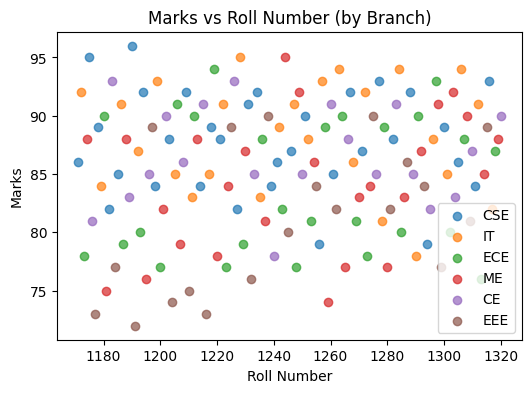

In [49]:
# 8. Scatter plot with different colors by branch
plt.figure(figsize=(6,4))          # set figure size (width=6, height=4)
branches = df['Student_Branch'].unique()

for branch in branches:        
    sub = df[df['Student_Branch'] == branch]      # filter rows for this branch only

    plt.scatter(sub['Student_Rollno'], sub['Student_Mark'],label=branch, alpha=0.7)
          
           #alpha=0.7 → makes points semi-transparent, so overlapping points are visible.


plt.title("Marks vs Roll Number (by Branch)")
plt.xlabel("Roll Number")
plt.ylabel("Marks")
plt.legend()          # Legend → shows which color belongs to which branch.
plt.show()